## Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading And Cleaning

### Loading the data file

In [2]:
customer = pd.read_csv("E-commerce Customer Behavior.csv", index_col = "Customer ID")
customer.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Customer ID,,,,,,,,,,
101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


### Checking the data info

In [3]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 101 to 450
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    350 non-null    object 
 1   Age                       350 non-null    int64  
 2   City                      350 non-null    object 
 3   Membership Type           350 non-null    object 
 4   Total Spend               350 non-null    float64
 5   Items Purchased           350 non-null    int64  
 6   Average Rating            350 non-null    float64
 7   Discount Applied          350 non-null    bool   
 8   Days Since Last Purchase  350 non-null    int64  
 9   Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 27.7+ KB


In [4]:
customer.describe()

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000
mean,33.597143,845.381714,12.600000,4.019143,26.588571
std,4.870882,362.058695,4.155984,0.580539,13.440813
min,26.000000,410.800000,7.000000,3.000000,9.000000
25%,30.000000,502.000000,9.000000,3.500000,15.000000
50%,32.500000,775.200000,12.000000,4.100000,23.000000
75%,37.000000,1160.600000,15.000000,4.500000,38.000000
max,43.000000,1520.100000,21.000000,4.900000,63.000000


### Finding missing value

In [5]:
customer[customer["Satisfaction Level"].isnull()]

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Customer ID,,,,,,,,,,
172,Female,37,Houston,Bronze,420.8,7,3.1,False,21,NaN
244,Female,37,Houston,Bronze,430.8,7,3.4,False,23,NaN


### Filling missing value

In [6]:
customer["Satisfaction Level"] = customer["Satisfaction Level"].fillna("Neutral")

In [17]:
# checking the changes
customer.loc[[172,244]]

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Customer ID,,,,,,,,,,
172,Female,37,Houston,Bronze,420.8,7,3.1,False,21,Neutral
244,Female,37,Houston,Bronze,430.8,7,3.4,False,23,Neutral


### Checking after data cleaning

In [8]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 101 to 450
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    350 non-null    object 
 1   Age                       350 non-null    int64  
 2   City                      350 non-null    object 
 3   Membership Type           350 non-null    object 
 4   Total Spend               350 non-null    float64
 5   Items Purchased           350 non-null    int64  
 6   Average Rating            350 non-null    float64
 7   Discount Applied          350 non-null    bool   
 8   Days Since Last Purchase  350 non-null    int64  
 9   Satisfaction Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 27.7+ KB


In [18]:
customer.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Customer ID,,,,,,,,,,
101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


## 2. Data Exploration: EDA

### Data Overview

In [9]:
customer.head(3)

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
Customer ID,,,,,,,,,,
101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied


### Who are our biggest customers by age group?

In [18]:
# total spend by age
total_spend_by_age = customer.groupby("Age")["Total Spend"].mean()
total_spend_by_age

Age
26     689.488889
27     710.820000
28    1492.183333
29    1290.218182
30    1325.645833
31    1144.600000
32     805.451515
33     820.640000
34     791.045833
35     800.088000
36     500.912000
37     432.050000
38     444.233333
41     484.416667
42     518.716667
43     507.950000
Name: Total Spend, dtype: float64

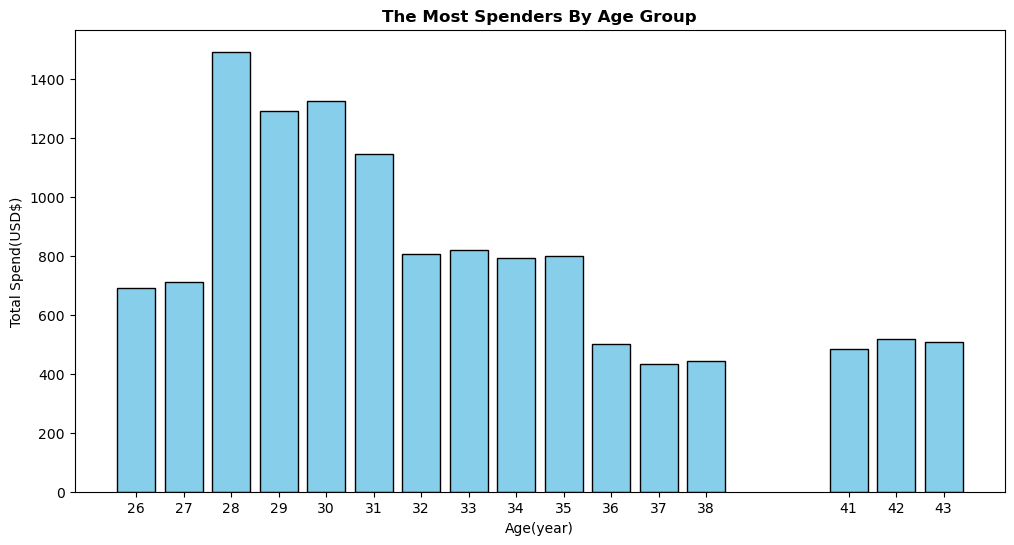

In [19]:
plt.figure(figsize = (12,6))
plt.bar(total_spend_by_age.index,total_spend_by_age.values, color="skyblue",edgecolor="black")
plt.xticks(total_spend_by_age.index)
plt.title("The Most Spenders By Age Group",fontweight="bold")
plt.ylabel("Total Spend(USD$)")
plt.xlabel("Age(year)")
plt.show()

### Which City has the highest spending customer?

In [28]:
total_spend_by_city= customer.groupby("City")["Total Spend"].mean()
total_spend_by_city

City
Chicago           499.882759
Houston           446.894828
Los Angeles       805.491525
Miami             690.389655
New York         1165.035593
San Francisco    1459.772414
Name: Total Spend, dtype: float64

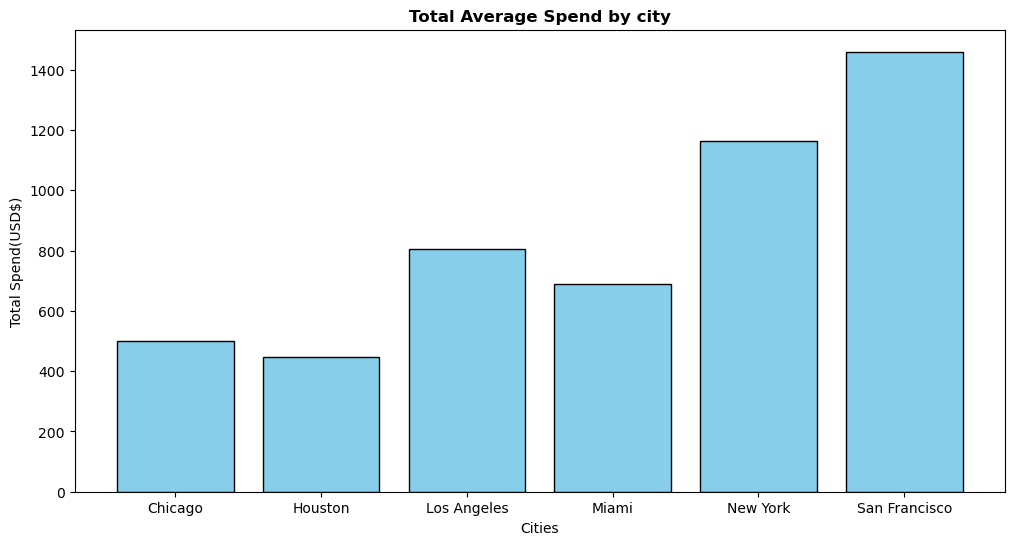

In [29]:
plt.figure(figsize = (12,6))
plt.bar(total_spend_by_city.index,total_spend_by_city.values, color = "skyblue",edgecolor="black")
plt.xlabel("Cities")
plt.ylabel("Total Spend(USD$)")
plt.title("Total Average Spend by city",fontweight="bold")
plt.show()

### Which member type customer spend money the most?

In [25]:
total_spend_by_type = customer.groupby("Membership Type")["Total Spend"].mean()
total_spend_by_type

Membership Type
Bronze     473.388793
Gold      1311.144444
Silver     748.432479
Name: Total Spend, dtype: float64

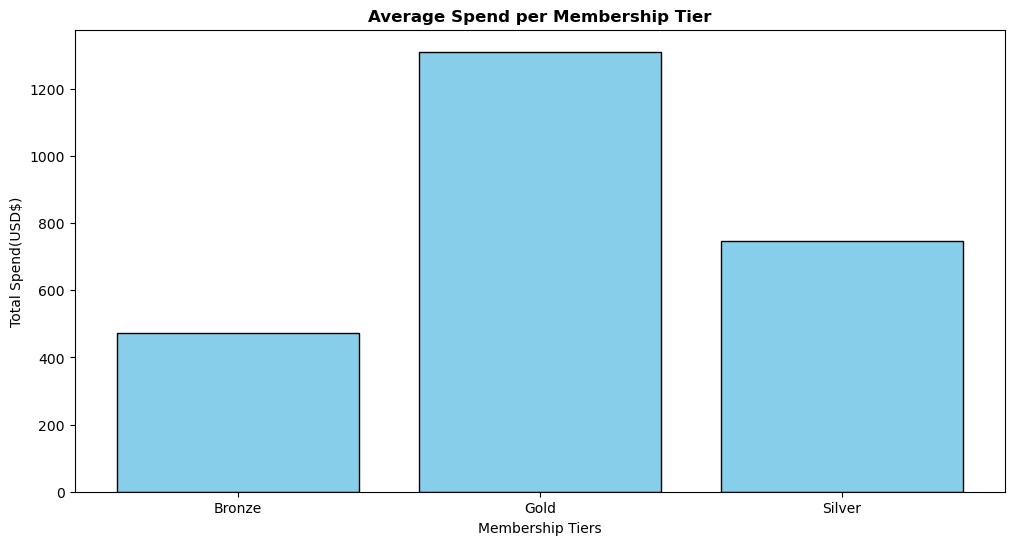

In [30]:
plt.figure(figsize = (12,6))
plt.bar(total_spend_by_type.index,total_spend_by_type.values,color = "skyblue",edgecolor="black")
plt.title("Average Spend per Membership Tier",color = "black",fontweight = "bold")
plt.xlabel("Membership Tiers")
plt.ylabel("Total Spend(USD$)")
plt.show()

### Which gender spend more on average?

In [31]:
total_spend_by_gender = customer.groupby("Gender")["Total Spend"].mean()
total_spend_by_gender

Gender
Female    703.828571
Male      986.934857
Name: Total Spend, dtype: float64

<Axes: ylabel='Total Spend'>

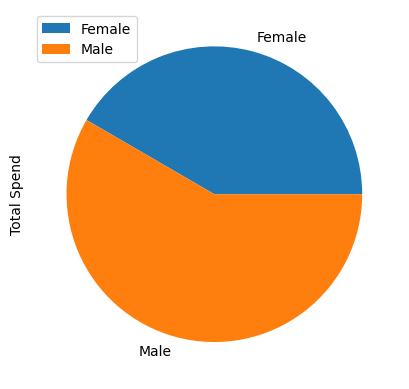

In [32]:
total_spend_by_gender.plot(kind = "pie",legend = "True")

### How are items purchased and total spend related?

In [33]:
corr_spend_discount = customer["Total Spend"].corr(customer["Items Purchased"])
corr_spend_discount

np.float64(0.9724247945494606)

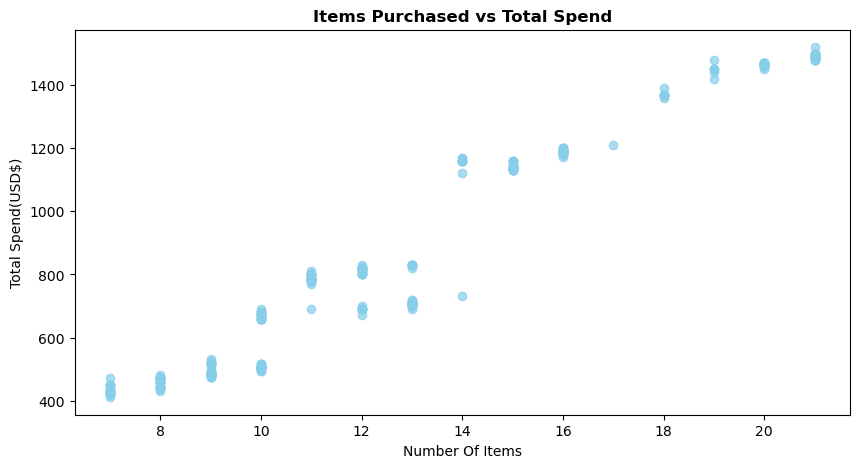

In [34]:
plt.figure(figsize=(10,5))
plt.scatter(x="Items Purchased", y="Total Spend", data=customer, alpha=0.7, color="skyblue")
plt.title("Items Purchased vs Total Spend",fontweight = "bold")
plt.xlabel("Number Of Items")
plt.ylabel("Total Spend(USD$)")
plt.show()

### The relationship between the discount applied and items purchased.

In [35]:
corr_discount_quantity =customer["Discount Applied"].corr(customer["Items Purchased"])
corr_discount_quantity

np.float64(-0.11428452933313087)

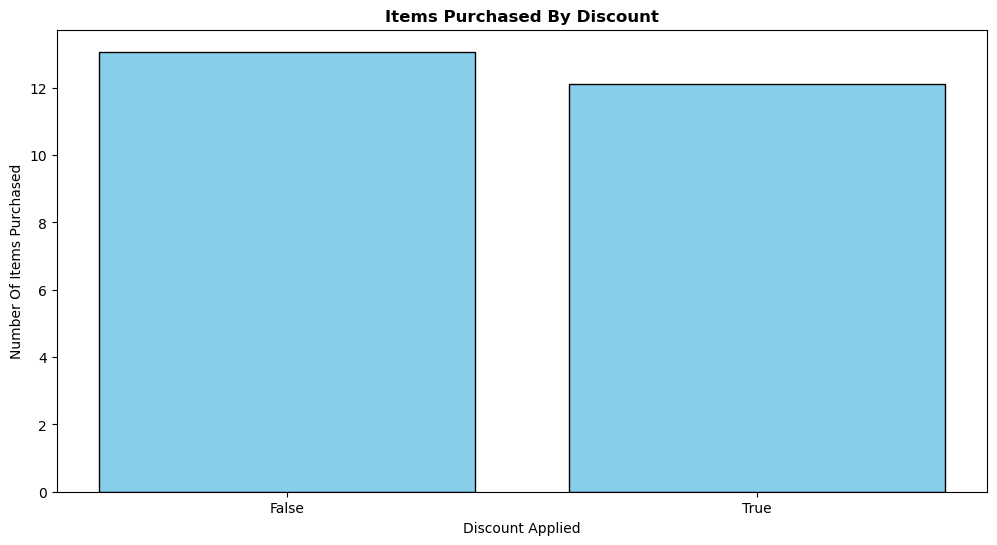

In [44]:
items_purchased_discount = customer.groupby("Discount Applied")["Items Purchased"].mean()
plt.figure(figsize = (12,6))
plt.bar(items_purchased_discount.index,items_purchased_discount.values,color = "skyblue",edgecolor="black")
plt.xticks([0,1],["False","True"])
plt.xlabel("Discount Applied")
plt.ylabel("Number Of Items Purchased")
plt.title("Items Purchased By Discount", fontweight= "bold")
plt.show()

### Which membership type customer has better loyalty?

In [37]:
customer_loyalty = customer.groupby("Membership Type")["Days Since Last Purchase"].mean()
customer_loyalty

Membership Type
Bronze    31.612069
Gold      17.940171
Silver    30.256410
Name: Days Since Last Purchase, dtype: float64

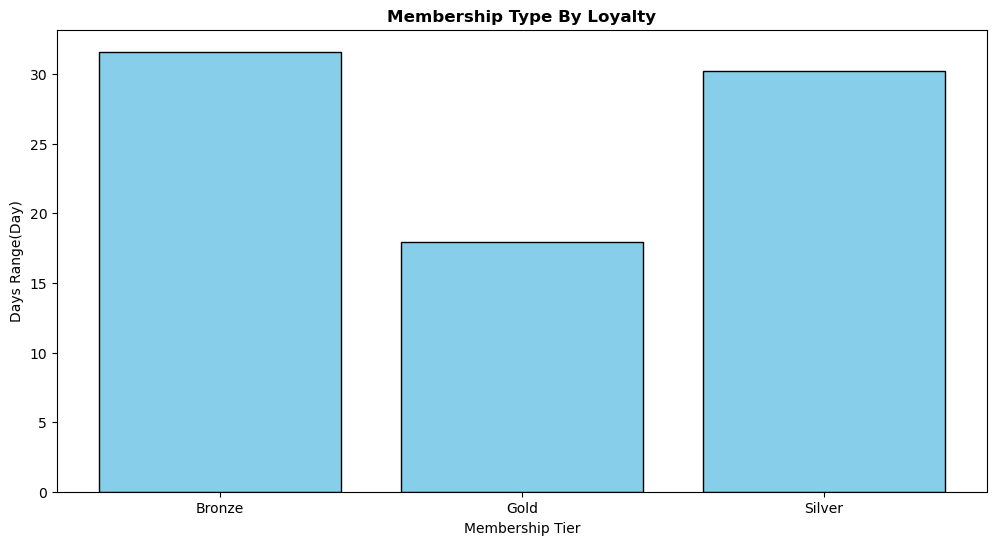

In [39]:
plt.figure(figsize = (12,6))
plt.bar(customer_loyalty.index, customer_loyalty.values,color = "skyblue",edgecolor="black")
plt.title("Membership Type By Loyalty",fontweight= "bold")
plt.xlabel("Membership Tier")
plt.ylabel("Days Range(Day)")
plt.show()